# 🥑 Avocado Data Analysis & Machine Learning Project

## 📌 Introduction

Avocados (Avocado) have become one of the most popular agricultural products globally, driven by increasing awareness of their nutritional benefits and rising demand in modern diets. As consumption continues to grow, understanding the factors that influence avocado pricing and classification has become essential for producers, retailers, and data analysts.

This project focuses on exploring and analyzing avocado sales data to uncover meaningful patterns and build predictive models. The dataset includes information on avocado prices, sales volume, product types (organic and conventional), and distribution across different regions and time periods.

The analysis is divided into key components. First, a regression approach is used to investigate how various factors, particularly sales volume, influence the average price of avocados. This helps in understanding the economic relationship between supply and pricing. Next, a classification model is developed to distinguish between organic and conventional avocados using machine learning techniques such as Logistic Regression.

Additionally, the project explores the potential of time-based analysis to study trends and patterns in avocado prices over time, offering insights into seasonality and market behavior.

By combining data cleaning, exploratory data analysis, and machine learning techniques, this project demonstrates how data-driven approaches can be applied to real-world agricultural and economic problems.

In [88]:
# import libraries
import pandas as pd
import numpy as np
import janitor
import seaborn as sns
from ipywidgets import interact
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from plotnine import *

In [89]:
# load your dataset
avocado = pd.read_csv("C:/Users/user/Downloads/avocado.csv")
avocado.head()

,Unnamed: 0,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,0,12/27/2015,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,1,12/20/2015,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2,12/13/2015,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,3,12/6/2015,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,4,11/29/2015,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


# Part 2: Avocado Type Classification 
Objective: Classify avocados as Organic or Conventional using  Logistic Regression or PCA 

# Data cleaning

In [90]:
# data info 
avocado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18249 entries, 0 to 18248
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    18249 non-null  int64  
 1   Date          18249 non-null  object 
 2   AveragePrice  18249 non-null  float64
 3   Total Volume  18249 non-null  float64
 4   4046          18249 non-null  float64
 5   4225          18249 non-null  float64
 6   4770          18249 non-null  float64
 7   Total Bags    18249 non-null  float64
 8   Small Bags    18249 non-null  float64
 9   Large Bags    18249 non-null  float64
 10  XLarge Bags   18249 non-null  float64
 11  type          18249 non-null  object 
 12  year          18249 non-null  int64  
 13  region        18249 non-null  object 
dtypes: float64(9), int64(2), object(3)
memory usage: 1.9+ MB


In [91]:
# fixing the column names
avocado2 = avocado.clean_names()
avocado2.head()

,unnamed_0,date,averageprice,total_volume,4046,4225,4770,total_bags,small_bags,large_bags,xlarge_bags,type,year,region
0,0,12/27/2015,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,1,12/20/2015,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2,12/13/2015,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,3,12/6/2015,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,4,11/29/2015,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


In [92]:
# remove column unnamed

avocado2 = avocado2.drop(columns = ["unnamed_0"])
avocado2.head()

,date,averageprice,total_volume,4046,4225,4770,total_bags,small_bags,large_bags,xlarge_bags,type,year,region
0,12/27/2015,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,12/20/2015,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,12/13/2015,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,12/6/2015,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,11/29/2015,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


In [93]:
# fixing average price column
avocado2. rename(columns = {"averageprice" : "average_price"}, inplace = True)
avocado2.head()

,date,average_price,total_volume,4046,4225,4770,total_bags,small_bags,large_bags,xlarge_bags,type,year,region
0,12/27/2015,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,12/20/2015,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,12/13/2015,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,12/6/2015,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,11/29/2015,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


In [94]:
# Convert Date column to datetime format
avocado2["date"] = pd.to_datetime(avocado2["date"])
avocado2.head()

,date,average_price,total_volume,4046,4225,4770,total_bags,small_bags,large_bags,xlarge_bags,type,year,region
0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


In [95]:
# checking missing values
avocado2.isnull().sum()

date             0
average_price    0
total_volume     0
4046             0
4225             0
4770             0
total_bags       0
small_bags       0
large_bags       0
xlarge_bags      0
type             0
year             0
region           0
dtype: int64

In [96]:
# checking for duplicates
avocado2.duplicated().sum()

np.int64(0)

In [97]:
# Extract features such as month and year 
avocado2["month"] = avocado2["date"].dt.month
avocado2.head()

,date,average_price,total_volume,4046,4225,4770,total_bags,small_bags,large_bags,xlarge_bags,type,year,region,month
0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany,12
1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany,12
2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany,12
3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany,12
4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany,11


In [98]:
# data describ

avocado2.describe()

,date,average_price,total_volume,4046,4225,4770,total_bags,small_bags,large_bags,xlarge_bags,year,month
count,18249,18249.000000,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,18249.000000,18249.000000,18249.000000
mean,2016-08-13 23:30:43.498273792,1.405978,8.506440e+05,2.930084e+05,2.951546e+05,2.283974e+04,2.396392e+05,1.821947e+05,5.433809e+04,3106.426507,2016.147899,6.177215
min,2015-01-04 00:00:00,0.440000,8.456000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,2015.000000,1.000000
25%,2015-10-25 00:00:00,1.100000,1.083858e+04,8.540700e+02,3.008780e+03,0.000000e+00,5.088640e+03,2.849420e+03,1.274700e+02,0.000000,2015.000000,3.000000
50%,2016-08-14 00:00:00,1.370000,1.073768e+05,8.645300e+03,2.906102e+04,1.849900e+02,3.974383e+04,2.636282e+04,2.647710e+03,0.000000,2016.000000,6.000000
75%,2017-06-04 00:00:00,1.660000,4.329623e+05,1.110202e+05,1.502069e+05,6.243420e+03,1.107834e+05,8.333767e+04,2.202925e+04,132.500000,2017.000000,9.000000
max,2018-03-25 00:00:00,3.250000,6.250565e+07,2.274362e+07,2.047057e+07,2.546439e+06,1.937313e+07,1.338459e+07,5.719097e+06,551693.650000,2018.000000,12.000000
std,NaN,0.402677,3.453545e+06,1.264989e+06,1.204120e+06,1.074641e+05,9.862424e+05,7.461785e+05,2.439660e+05,17692.894652,0.939938,3.534130


In [99]:
avocado2.skew(numeric_only = True)

average_price     0.580303
total_volume      9.007687
4046              8.648220
4225              8.942466
4770             10.159396
total_bags        9.756072
small_bags        9.540660
large_bags        9.796455
xlarge_bags      13.139751
year              0.215339
month             0.106617
dtype: float64

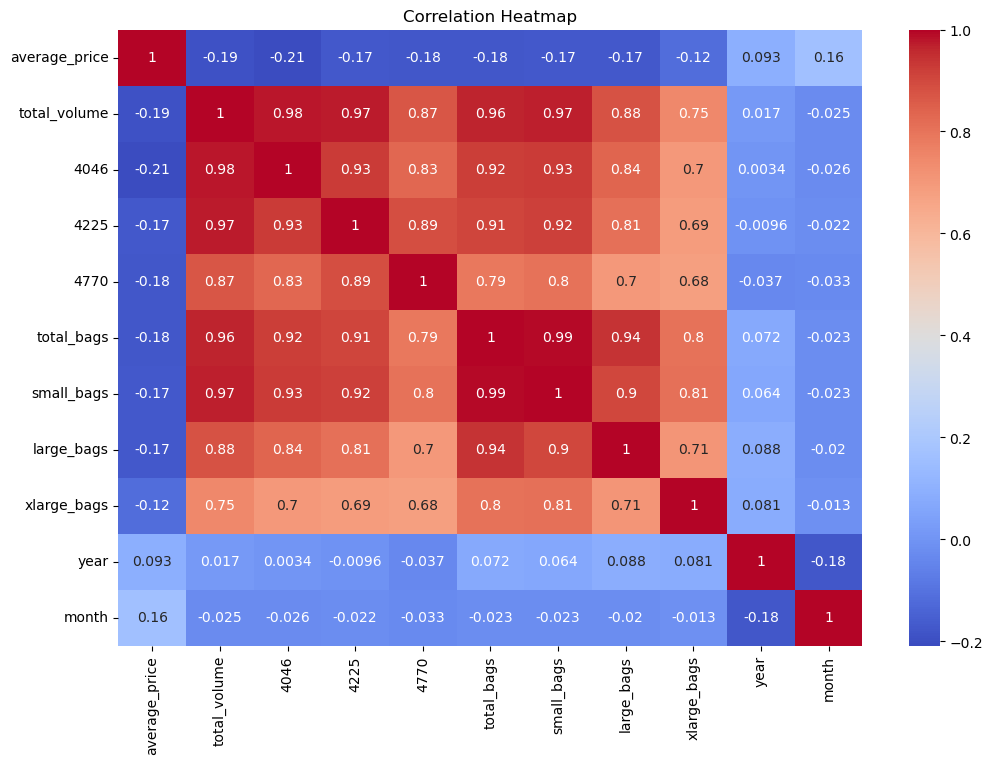

In [100]:
plt.figure(figsize=(12,8))
sns.heatmap(avocado2.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [101]:
avocado2.shape

(18249, 14)

In [102]:
avocado2['type'] = avocado['type'].map({'organic': 1, 'conventional': 0})
avocado2.head()

,date,average_price,total_volume,4046,4225,4770,total_bags,small_bags,large_bags,xlarge_bags,type,year,region,month
0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,0,2015,Albany,12
1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,0,2015,Albany,12
2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,0,2015,Albany,12
3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,0,2015,Albany,12
4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,0,2015,Albany,11


# Data Preprocessing

In [103]:
# selecting relevant features 
avocado2 = avocado2.drop(["small_bags", "large_bags", "xlarge_bags", "date", "region"], axis = 1)
avocado2.head()

,average_price,total_volume,4046,4225,4770,total_bags,type,year,month
0,1.33,64236.62,1036.74,54454.85,48.16,8696.87,0,2015,12
1,1.35,54876.98,674.28,44638.81,58.33,9505.56,0,2015,12
2,0.93,118220.22,794.70,109149.67,130.50,8145.35,0,2015,12
3,1.08,78992.15,1132.00,71976.41,72.58,5811.16,0,2015,12
4,1.28,51039.60,941.48,43838.39,75.78,6183.95,0,2015,11


In [104]:
avocado2.shape

(18249, 9)

# Data spliting

In [105]:
from sklearn.model_selection import train_test_split

In [106]:
#independent_variables

x = avocado2.drop("type", axis = 1)
x.head()

,average_price,total_volume,4046,4225,4770,total_bags,year,month
0,1.33,64236.62,1036.74,54454.85,48.16,8696.87,2015,12
1,1.35,54876.98,674.28,44638.81,58.33,9505.56,2015,12
2,0.93,118220.22,794.70,109149.67,130.50,8145.35,2015,12
3,1.08,78992.15,1132.00,71976.41,72.58,5811.16,2015,12
4,1.28,51039.60,941.48,43838.39,75.78,6183.95,2015,11


In [107]:
# dependent_variables

y = avocado2["type"]
y.head()

0    0
1    0
2    0
3    0
4    0
Name: type, dtype: int64

In [108]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [109]:
x_train.shape

(14599, 8)

In [110]:
x_test.shape

(3650, 8)

# Initiate and train the model

In [111]:
from sklearn.linear_model import LogisticRegression

class_model = LogisticRegression()
class_model.fit(x_train, y_train)

C:\Users\user\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression


LogisticRegression()

In [120]:
class_model.intercept_

array([1.338804e-05])

In [121]:
class_model.coef_

array([[ 0.04285349,  0.12663118, -0.12666686, -0.12665541, -0.12695356,
        -0.12661964,  0.00132386, -0.06931022]])

# Preprocess: Standardization

In [116]:
from sklearn.preprocessing import StandardScaler

sca = StandardScaler()

x_train_scaled = sca.fit_transform(x_train)

x_train_scaled


x_scaled_avocado = pd.DataFrame(x_train_scaled, columns = x_train.columns)
x_scaled_avocado.head()

,average_price,total_volume,4046,4225,4770,total_bags,year,month
0,1.178674,-0.247683,-0.235928,-0.245519,-0.211662,-0.241649,0.905234,1.360639
1,-1.475662,-0.079312,-0.110923,-0.118244,-0.011670,0.010839,-0.158217,-1.471649
2,1.501164,-0.247362,-0.234417,-0.244132,-0.211662,-0.244176,-0.158217,1.360639
3,-0.954717,-0.206482,-0.173141,-0.213823,-0.210415,-0.216627,-1.221669,-1.188420
4,0.310433,-0.237356,-0.235916,-0.213896,-0.211662,-0.244402,-0.158217,-0.055505


In [117]:
class_model2 = LogisticRegression()

class_model2.fit(x_scaled_avocado, y_train)

LogisticRegression()

# Model Result

In [118]:
class_model2.intercept_

array([-8.11189458])

In [119]:
class_model2.coef_

array([[  1.80898302,  -8.52602351, -14.23337784, -14.36688088,
        -12.04942485,   7.37398315,  -0.3188103 ,  -0.4484158 ]])

In [124]:
lr = pd.DataFrame(class_model2.coef_.T, x_scaled_avocado.columns, columns = ["Coefficient"])

lr

,Coefficient
average_price,1.808983
total_volume,-8.526024
4046,-14.233378
4225,-14.366881
4770,-12.049425
total_bags,7.373983
year,-0.318810
month,-0.448416


In [125]:
import numpy as np
lr = pd.DataFrame(np.exp(class_model2.coef_), columns =  x_scaled_avocado.columns)

lr

,average_price,total_volume,4046,4225,4770,total_bags,year,month
0,6.104236,0.000198,6.584496e-07,5.761597e-07,0.000006,1593.970172,0.727013,0.638639


# Model Evaluation

In [126]:
class_pred = class_model2.predict(x_scaled_avocado)

In [128]:
from sklearn import metrics

print(metrics.classification_report(y_train, class_pred))

              precision    recall  f1-score   support

           0       0.94      0.90      0.92      7306
           1       0.90      0.94      0.92      7293

    accuracy                           0.92     14599
   macro avg       0.92      0.92      0.92     14599
weighted avg       0.92      0.92      0.92     14599



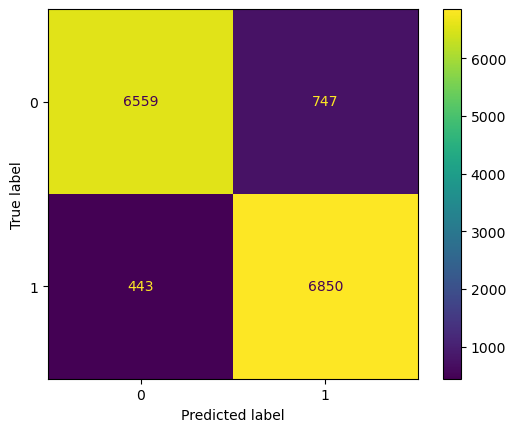

In [129]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pylab as plt

ConfusionMatrixDisplay.from_predictions(y_train, class_pred)

# 🔍 Model Performance

The Logistic Regression model achieved an accuracy of approximately 92%, indicating that the model correctly classifies avocado types (organic vs conventional) with high accuracy.

The precision, recall, and F1-scores for both classes are high and balanced:
	•	Class 0 (e.g., Conventional)
	•	Class 1 (e.g., Organic)

👉 This shows the model performs well for both avocado types without bias.

⸻

# 🔲 Confusion Matrix Interpretation

The confusion matrix shows that most predictions fall along the diagonal, indicating correct classification.

	•	A large number of conventional avocados were correctly classified
	•	A large number of organic avocados were correctly classified
	•	Misclassifications are relatively small

👉 This confirms that the model can effectively distinguish between avocado types

# 📌 Final Conclusion

In this notebook, Logistic Regression was used to classify avocado types into organic and conventional categories. The model achieved an accuracy of approximately 92%, indicating strong predictive performance.

The evaluation metrics, including precision, recall, and F1-score, show that the model performs consistently across both classes. The confusion matrix further confirms that most observations are correctly classified, with only a small number of misclassifications.

These results suggest that the selected features, such as total volume and region, provide sufficient information to distinguish between avocado types.

In conclusion, Logistic Regression proves to be an effective model for classifying avocado types and demonstrates the usefulness of classification techniques in identifying patterns within the dataset